In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv('healthcare-dataset-stroke-data.csv')
# drop id, format bmi, remove 'Other' gender
df = df.drop(columns=['id'])
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
df = df[df['gender'] != 'Other'].copy()

X = df.drop('stroke', axis=1)
y = df['stroke']

# split first to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

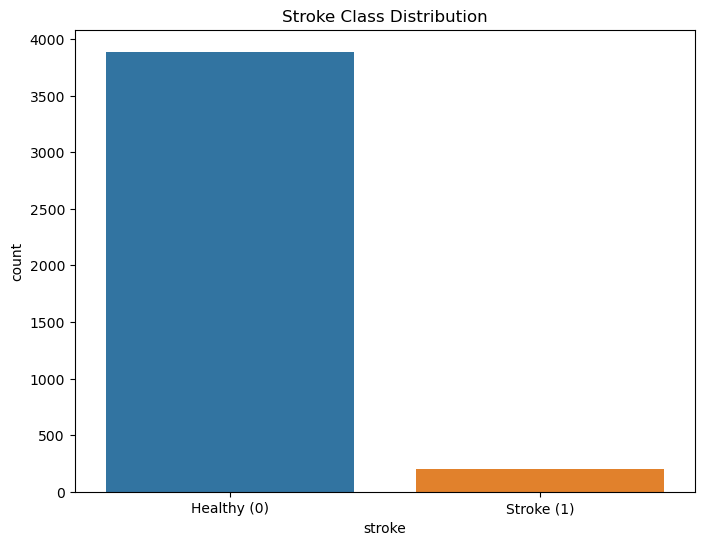

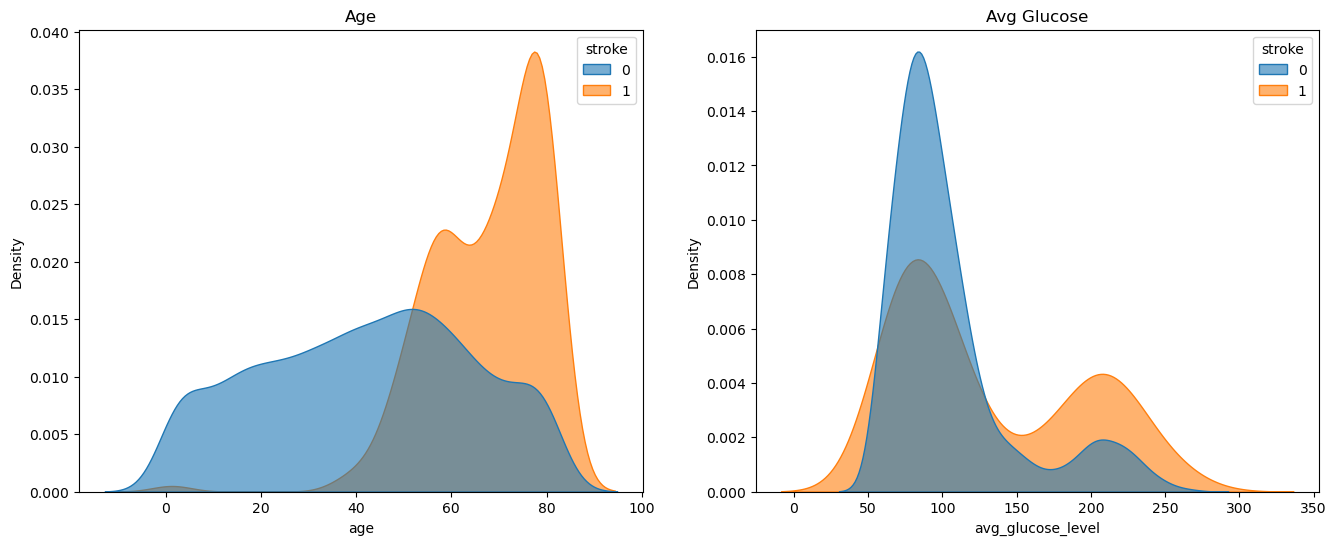

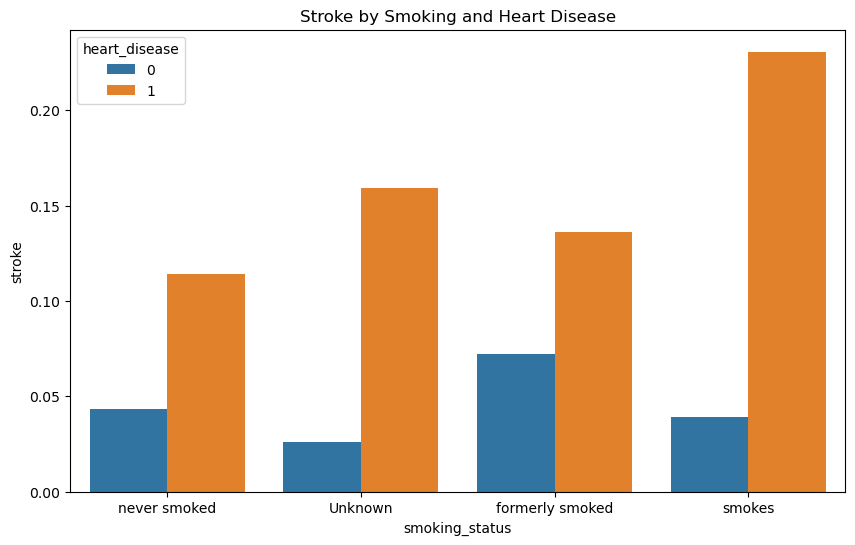

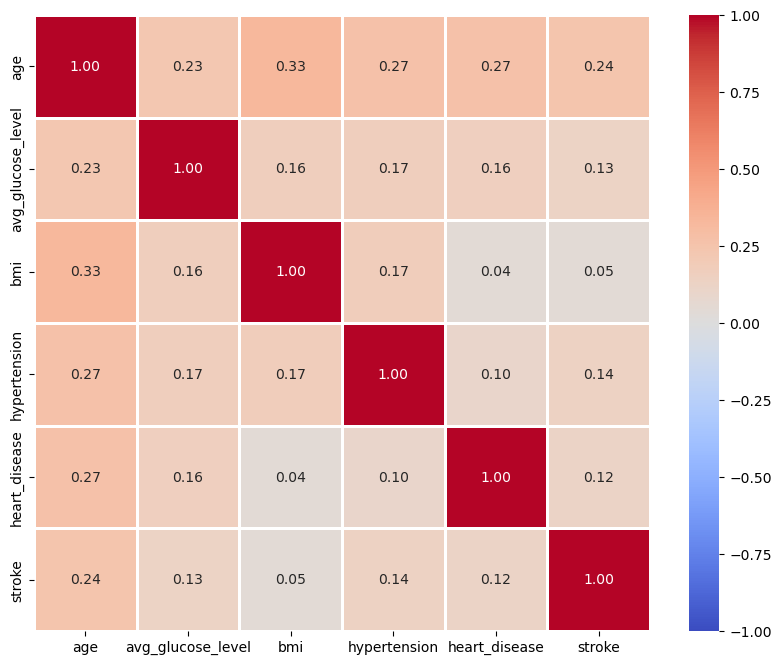

In [7]:
# eda on training set only
df_train_eda = pd.concat([X_train, y_train], axis=1)

# stroke distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df_train_eda, x='stroke', hue='stroke', legend=False)
plt.xticks(ticks=[0, 1], labels=['Healthy (0)', 'Stroke (1)'])
plt.title('Stroke Class Distribution')
plt.show()

# age and glucose kde
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.kdeplot(data=df_train_eda, x='age', hue='stroke', fill=True, common_norm=False, ax=axes[0], alpha=0.6)
axes[0].set_title('Age')
sns.kdeplot(data=df_train_eda, x='avg_glucose_level', hue='stroke', fill=True, common_norm=False, ax=axes[1], alpha=0.6)
axes[1].set_title('Avg Glucose')
plt.show()

# smoking, heart disease and stroke
plt.figure(figsize=(10, 6))
sns.barplot(data=df_train_eda, x='smoking_status', y='stroke', hue='heart_disease', errorbar=None)
plt.title('Stroke by Smoking and Heart Disease')
plt.show()

# correlation heatmap
num_cols = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']
plt.figure(figsize=(10, 8))
sns.heatmap(df_train_eda[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True, linewidths=1)
plt.show()